<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/DeepLearning/8_VanishingGradientDropputWeightInit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vanishing Gradient

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


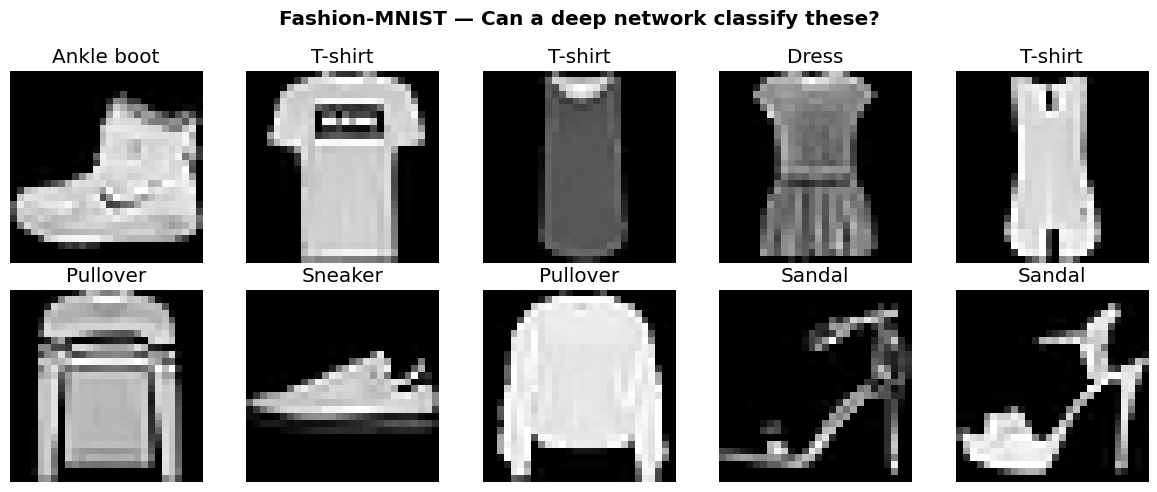

Train: (60000, 28, 28)  |  Test: (10000, 28, 28)  |  Classes: 10


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Show samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.suptitle("Fashion-MNIST — Can a deep network classify these?", fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}  |  Classes: {len(class_names)}")

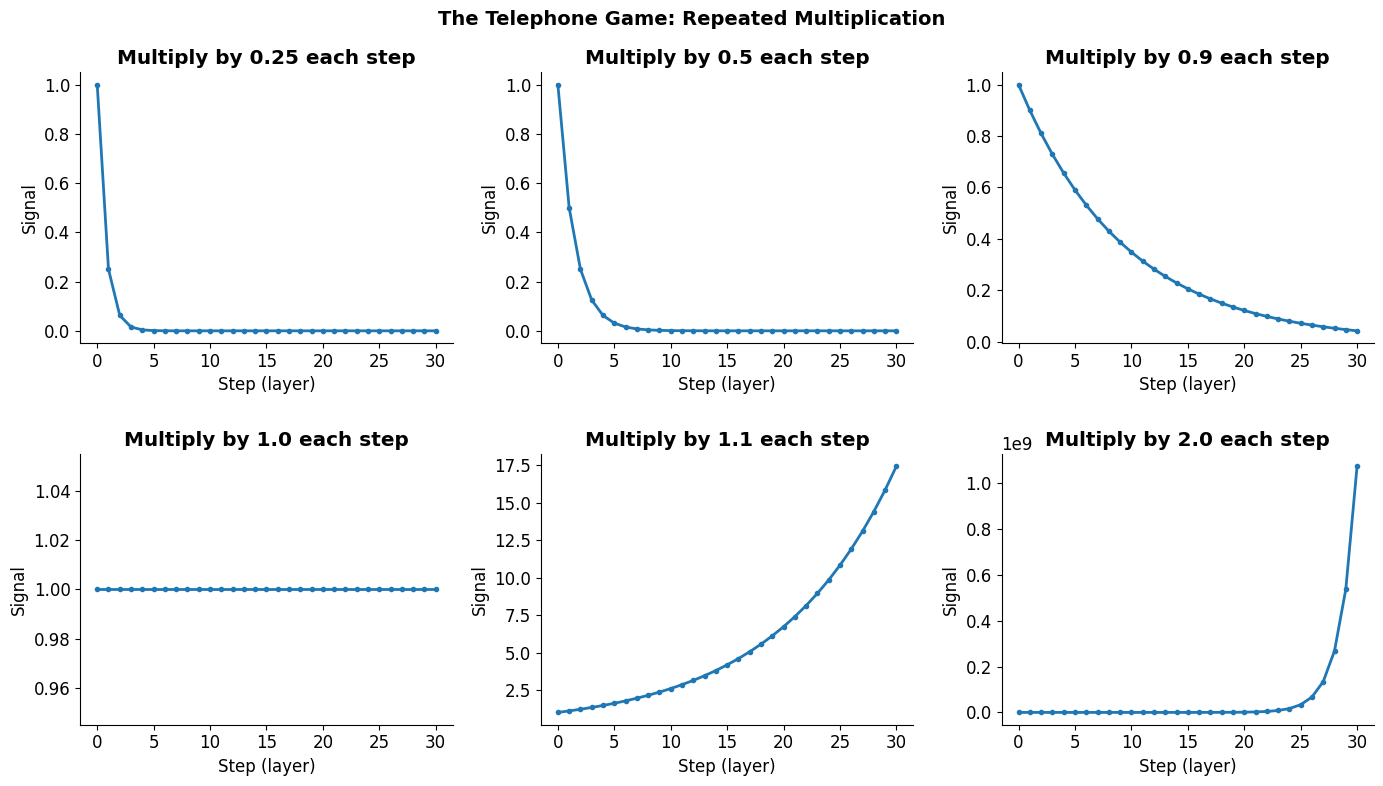

In [ ]:
factors = [0.25, 0.5, 0.9, 1.0, 1.1, 2.0]
n_steps = 30

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, f in zip(axes.flat, factors):
    values = [f**i for i in range(n_steps + 1)]
    ax.plot(values, 'o-', markersize=3, linewidth=2)
    ax.set_title(f"Multiply by {f} each step", fontweight='bold')
    ax.set_xlabel("Step (layer)")
    ax.set_ylabel("Signal")

plt.suptitle("The Telephone Game: Repeated Multiplication", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Sigmoid and ReLU

In [ ]:
# Define activation functions and their derivatives

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (np.array(x) > 0).astype(float)

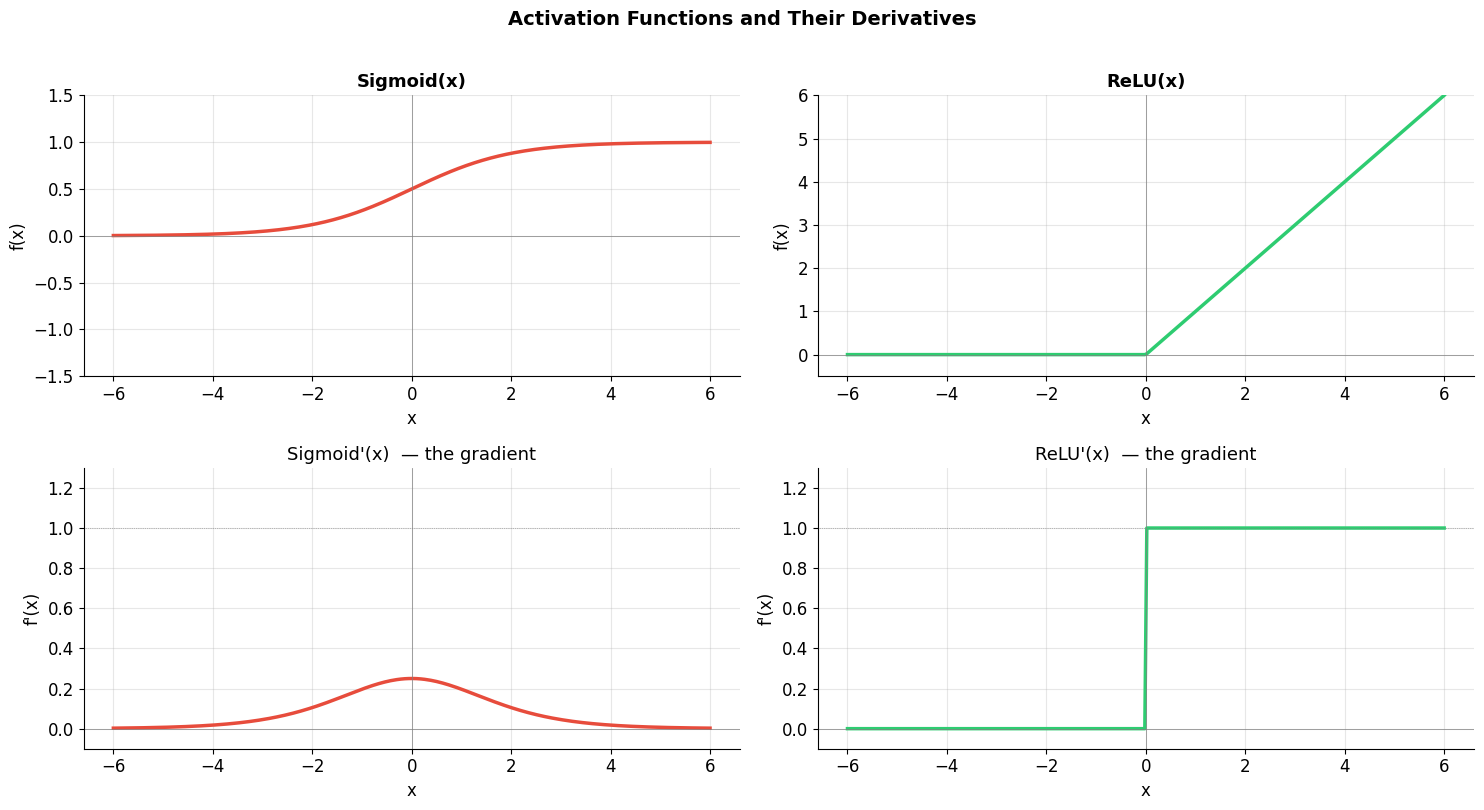

In [ ]:
x = np.linspace(-6, 6, 300)

activations = [
    ('Sigmoid', sigmoid, sigmoid_derivative, '#e74c3c'),
    ('ReLU', relu, relu_derivative, '#2ecc71'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

for i, (name, func, deriv, color) in enumerate(activations):
    # Function
    ax = axes[0, i]
    ax.plot(x, func(x), color=color, linewidth=2.5)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(f'{name}(x)', fontsize=13, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.5, 1.5) if name != 'ReLU' else ax.set_ylim(-0.5, 6)

    # Derivative
    ax = axes[1, i]
    ax.plot(x, deriv(x), color=color, linewidth=2.5)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axhline(y=1, color='gray', linewidth=0.5, linestyle=':')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(f"{name}'(x)  — the gradient", fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel("f'(x)")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.1, 1.3)

plt.suptitle('Activation Functions and Their Derivatives', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Let's look at the maximum possible gradients

print("Maximum gradient values:")
print(f"  Sigmoid: max derivative = {sigmoid_derivative(0):.4f}")
print(f"  ReLU:    max derivative = {relu_derivative(1):.4f}")
print()
print("This is the crux of the vanishing gradient problem:")
print("If the maximum gradient through a single layer is 0.25 (sigmoid),")
print("then through N layers, the gradient gets multiplied N times.")

Maximum gradient values:
  Sigmoid: max derivative = 0.2500
  ReLU:    max derivative = 1.0000

This is the crux of the vanishing gradient problem:
If the maximum gradient through a single layer is 0.25 (sigmoid),
then through N layers, the gradient gets multiplied N times.


During backpropagation, the gradient of the loss with respect to an early layer's weights passes through **every subsequent layer's activation function**. By the chain rule:

$$\frac{\partial \text{Loss}}{\partial w_1} = \frac{\partial \text{Loss}}{\partial a_N} \cdot \sigma'(z_N) \cdot \sigma'(z_{N-1}) \cdots \sigma'(z_1)$$

In [ ]:

np.random.seed(42)
num_layers = 20
num_simulations = 500

def simulate_gradient_flow(derivative_fn, num_layers, num_sims, input_scale=1.0):
    """Simulate gradient magnitude after passing through N layers."""
    all_gradients = np.zeros((num_sims, num_layers + 1))

    for sim in range(num_sims):
        gradient = 1.0  # Start with gradient = 1 at the output
        all_gradients[sim, 0] = gradient

        for layer in range(num_layers):
            # Random pre-activation value (what the activation function receives)
            z = abs(np.random.randn() * input_scale)
            # Multiply gradient by local derivative
            gradient *= derivative_fn(z)
            all_gradients[sim, layer + 1] = abs(gradient)

    return all_gradients

grad_sigmoid = simulate_gradient_flow(sigmoid_derivative, num_layers, num_simulations)
grad_relu = simulate_gradient_flow(relu_derivative, num_layers, num_simulations)

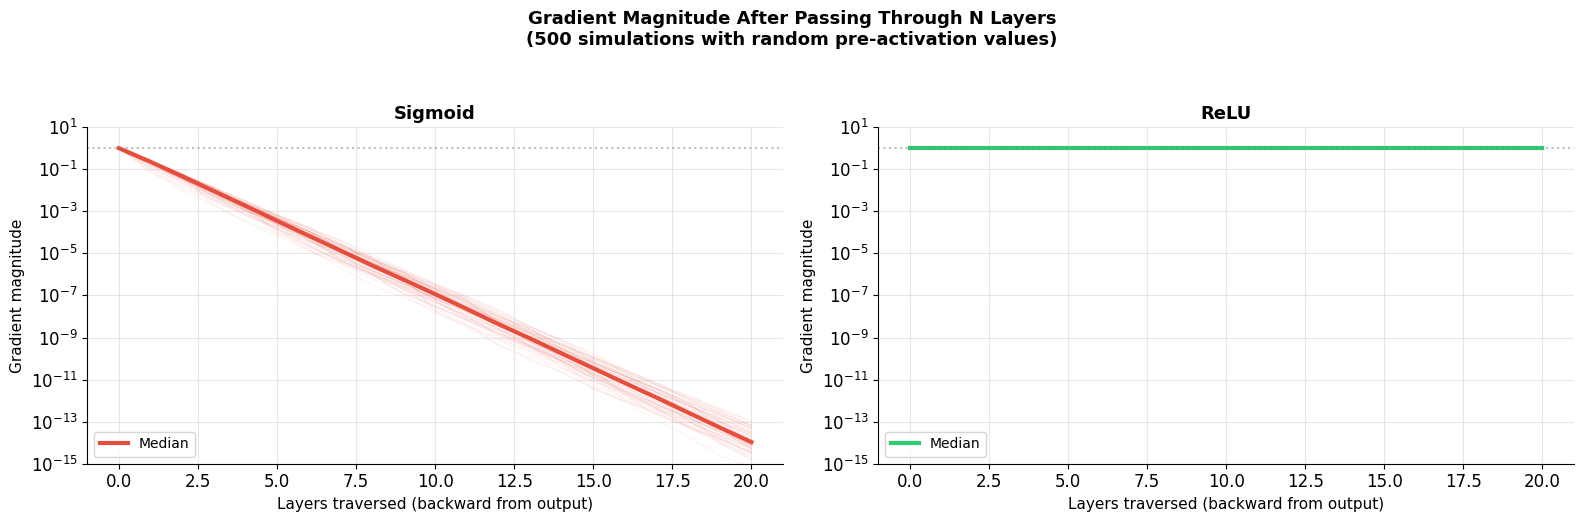

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

data_and_labels = [
    (grad_sigmoid, 'Sigmoid', '#e74c3c'),
    (grad_relu, 'ReLU', '#2ecc71'),
]

for ax, (grads, name, color) in zip(axes, data_and_labels):
    # Plot individual simulation traces (transparent)
    for i in range(min(50, num_simulations)):
        ax.plot(range(num_layers + 1), grads[i], color=color, alpha=0.07, linewidth=0.8)

    # Plot median
    median = np.median(grads, axis=0)
    ax.plot(range(num_layers + 1), median, color=color, linewidth=3, label='Median')

    ax.set_xlabel('Layers traversed (backward from output)', fontsize=11)
    ax.set_ylabel('Gradient magnitude', fontsize=11)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(1e-15, 10)
    ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Magnitude After Passing Through N Layers\n(500 simulations with random pre-activation values)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

## Training a Multi-Layer Neural Network

Now, let's build and train a simple multi-layer neural network using TensorFlow's Keras API to classify the Fashion-MNIST images. We'll use the ReLU activation function for hidden layers due to its better gradient flow properties compared to Sigmoid, which we observed earlier.

In [ ]:
# Define the model architecture
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Input layer: flatten 28x28 images
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(64, activation='relu'),   # Another hidden layer with 64 neurons and ReLU activation
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

The model is now defined and compiled. Next, we will train it using the `x_train` and `y_train` data.

In [ ]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=10, # Number of training epochs
    validation_data=(x_test, y_test) # Evaluate on test data after each epoch
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8265 - loss: 0.4892 - val_accuracy: 0.8558 - val_loss: 0.4097
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8663 - loss: 0.3658 - val_accuracy: 0.8612 - val_loss: 0.3790
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8779 - loss: 0.3287 - val_accuracy: 0.8617 - val_loss: 0.3770
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8868 - loss: 0.3050 - val_accuracy: 0.8642 - val_loss: 0.3695
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8930 - loss: 0.2868 - val_accuracy: 0.8715 - val_loss: 0.3577
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8973 - loss: 0.2733 - val_accuracy: 0.8689 - val_loss: 0.3690
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9027 - loss: 0.2604 - val_accuracy: 0.8705 - val_loss: 0.3598
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9063 - loss: 0.2484 - 

### Evaluating the First Model

Let's visualize the training and validation accuracy and loss to understand the model's performance and check for overfitting/underfitting.

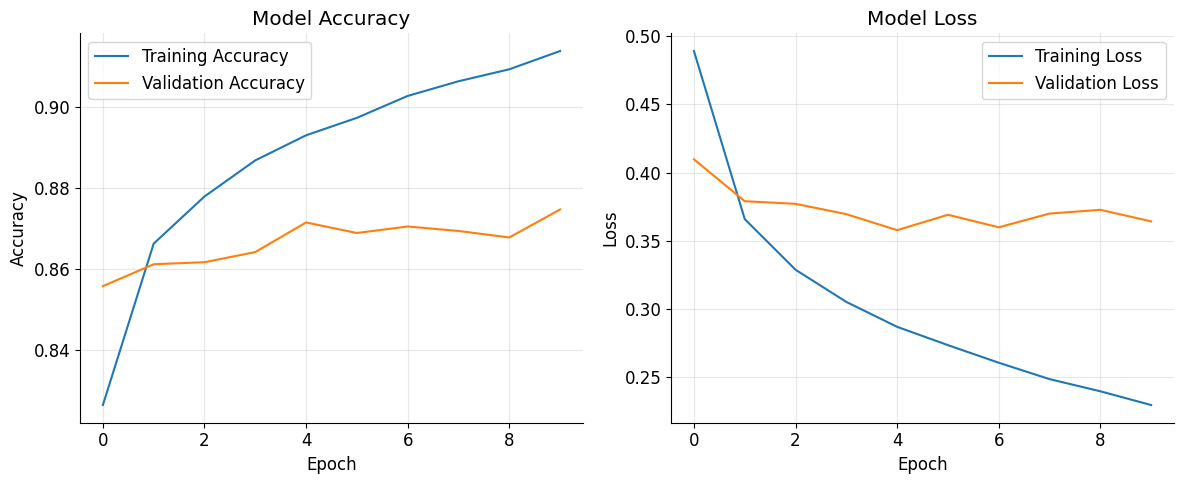


Final Training Accuracy: 0.9137
Final Validation Accuracy: 0.8747
Final Training Loss: 0.2294
Final Validation Loss: 0.3642


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display final training and validation metrics
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

### Addressing Overfitting with Dropout

As observed from the previous plots, the model exhibits signs of overfitting. The training accuracy is significantly higher than the validation accuracy, and the training loss is lower than the validation loss. This means the model has learned the training data too well, including its noise, and is not generalizing effectively to unseen data.

To mitigate overfitting, we will use **Dropout**. Dropout is a regularization technique where a random selection of neurons is ignored during training. They are 'dropped out' randomly, meaning their contribution to the activation of downstream neurons is temporarily removed, and no weights are updated through them. This forces the network to learn more robust features and prevents co-adaptation of neurons, which is a common cause of overfitting.

### Training a Model with Dropout

In [ ]:
# Define the model architecture with Dropout layers
model_dropout = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Input layer: flatten 28x28 images
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons
    keras.layers.Dropout(0.3),                   # Dropout layer with 30% dropout rate
    keras.layers.Dense(64, activation='relu'),   # Another hidden layer with 64 neurons
    keras.layers.Dropout(0.3),                   # Another Dropout layer with 30% dropout rate
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons and softmax activation
])

# Compile the model
model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

# Display model summary
model_dropout.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

The new model with dropout layers is defined and compiled. Now, let's train it.

In [ ]:
# Train the model with dropout
history_dropout = model_dropout.fit(
    x_train, y_train,
    epochs=10, # Number of training epochs
    validation_data=(x_test, y_test) # Evaluate on test data after each epoch
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7742 - loss: 0.6308 - val_accuracy: 0.8361 - val_loss: 0.4646
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8338 - loss: 0.4602 - val_accuracy: 0.8509 - val_loss: 0.4062
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8472 - loss: 0.4238 - val_accuracy: 0.8603 - val_loss: 0.3927
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8559 - loss: 0.4036 - val_accuracy: 0.8636 - val_loss: 0.3818
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8591 - loss: 0.3867 - val_accuracy: 0.8657 - val_loss: 0.3668
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8614 - loss: 0.3778 - val_accuracy: 0.8692 - val_loss: 0.3777
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8675 - loss: 0.3628 - val_accuracy: 0.8692 - val_loss: 0.3698
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8706 - loss: 0.3544 - 

### Evaluating the Model with Dropout

Let's visualize the training and validation accuracy and loss for the model trained with dropout to see if overfitting has been reduced.

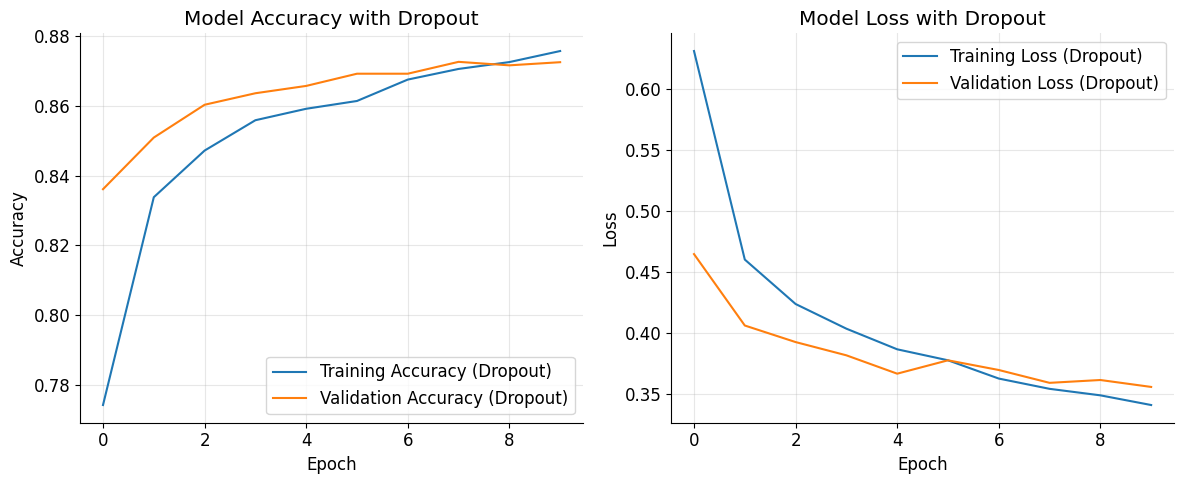


Final Training Accuracy (Dropout): 0.8757
Final Validation Accuracy (Dropout): 0.8725
Final Training Loss (Dropout): 0.3412
Final Validation Loss (Dropout): 0.3560


In [ ]:
# Plot training & validation accuracy values for the dropout model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['accuracy'], label='Training Accuracy (Dropout)')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy (Dropout)')
plt.title('Model Accuracy with Dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation loss values for the dropout model
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'], label='Training Loss (Dropout)')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss (Dropout)')
plt.title('Model Loss with Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display final training and validation metrics for the dropout model
print(f"\nFinal Training Accuracy (Dropout): {history_dropout.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy (Dropout): {history_dropout.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss (Dropout): {history_dropout.history['loss'][-1]:.4f}")
print(f"Final Validation Loss (Dropout): {history_dropout.history['val_loss'][-1]:.4f}")

# Random Initialization of Weights!?

In [ ]:
import numpy as np
import math
import pandas as pd

np.set_printoptions(suppress=True, precision=4)

def init_weights(shape, mode, rng):
    fan_in, fan_out = shape

    if mode == "tiny":
        # deliberately too small
        std = 0.01
        return rng.normal(0, std, size=shape)

    elif mode == "large":
        # deliberately too large
        std = 1.0
        return rng.normal(0, std, size=shape)

    elif mode == "glorot_uniform": # xavier
        # Xavier / Glorot
        limit = math.sqrt(6.0 / (fan_in + fan_out))
        return rng.uniform(-limit, limit, size=shape)

    elif mode == "he_normal": # kaming
        # He initialization
        std = math.sqrt(2.0 / fan_in)
        return rng.normal(0, std, size=shape)

    else:
        raise ValueError(f"Unknown mode: {mode}")


def activate(x):

    return np.maximum(0, x)
    # return 1 / (1 + np.exp(-x))



def forward_pass_demo(init_mode, activation="relu", layers=5, width=100, batch_size=512, seed=0):
    rng = np.random.default_rng(seed)

    # same random input for every experiment
    x = rng.normal(0, 1, size=(batch_size, width))
    a = x.copy()

    rows = []

    for layer in range(1, layers + 1):
        W = init_weights((width, width), init_mode, rng)

        z = a @ W
        a = activate(z)

        row = {
            "layer": layer,
            "pre_std": z.std(),
            "post_std": a.std(),
        }


        row["frac_zero"] = np.mean(a == 0)


        rows.append(row)

    return pd.DataFrame(rows)


# -----------------------------------------
# Run for ReLU
# -----------------------------------------
print("\n===== ReLU experiments =====\n")
for mode in ["tiny", "large", "glorot_uniform", "he_normal"]:
    df = forward_pass_demo(init_mode=mode, activation="relu", layers=5, width=100, batch_size=512, seed=0)
    print(f"\n--- {mode} ---")
    print(df.round(4).to_string(index=False))




===== ReLU experiments =====


--- tiny ---
 layer  pre_std  post_std  frac_zero
     1   0.0996    0.0580     0.5003
     2   0.0072    0.0041     0.5207
     3   0.0005    0.0003     0.4867
     4   0.0000    0.0000     0.5030
     5   0.0000    0.0000     0.4500

--- large ---
 layer    pre_std   post_std  frac_zero
     1     9.9638     5.8023     0.5003
     2    71.6843    40.6535     0.5207
     3   489.2192   283.1215     0.4867
     4  3271.6895  1802.5082     0.5030
     5 22233.2986 13753.0054     0.4500

--- glorot_uniform ---
 layer  pre_std  post_std  frac_zero
     1   1.0016    0.5834     0.5003
     2   0.7072    0.4102     0.5039
     3   0.4867    0.2662     0.5359
     4   0.3128    0.1836     0.5232
     5   0.2152    0.1200     0.5518

--- he_normal ---
 layer  pre_std  post_std  frac_zero
     1   1.4091    0.8206     0.5003
     2   1.4337    0.8131     0.5207
     3   1.3837    0.8008     0.4867
     4   1.3087    0.7210     0.5030
     5   1.2577    0.7780   